- https://pypi.org/project/xee/0.1.0/
- https://github.com/google/Xee/blob/main/docs/quickstart.md
- https://github.com/google/Xee/blob/main/docs/migration-guide-v0.1.0.md
- https://www.youtube.com/watch?v=KuSC6MAUhFE&t=1212s
- https://pypi.org/project/xee/0.1.0/#history



- https://github.com/google/Xee
- https://medium.com/google-earth/python-powers-up-the-rise-of-the-python-api-for-earth-engine-056741eb1b75

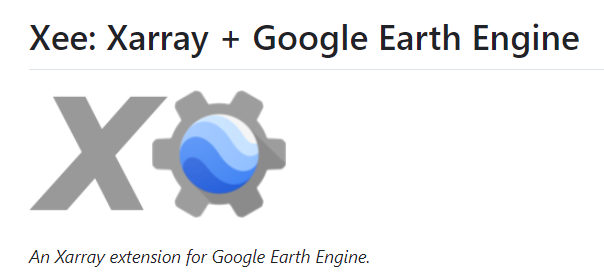

Exemplo 1:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00
Dimensions: ('time', 'y', 'x')
CRS: EPSG:4326
Transform: (0.1, 0, -180.05, 0, -0.1, 90.05)
Shape: (3601, 1801)


<xarray.Dataset> Size: 19GB
Dimensions:                                                    (time: 5,
                                                                y: 1801, x: 3601)
Coordinates:
  * time                                                       (time) datetime64[ns] 40B ...
  * y                                                          (y) float64 14kB ...
  * x                                                          (x) float64 29kB ...
Data variables: (12/150)
    dewpoint_temperature_2m                                    (time, y, x) float32 130MB ...
    temperature_2m                                             (time, y, x) float32 130MB ...
    skin_temperature                                           (time, y, x) float32 130MB ...
    soil_temperature_level_1                                   (time, y, x) float32 130MB ...
    soil_temperature_level_2                                   (time, y, x) float32 130MB ...
    soil_temperature_level_3                                   (time, y, x) float32 130MB ...
    ...                                                         ...
    total_precipitation_min                                    (time, y, x) float32 130MB ...
    total_precipitation_max                                    (time, y, x) float32 130MB ...
    leaf_area_index_high_vegetation_min                        (time, y, x) float32 130MB ...
    leaf_area_index_high_vegetation_max                        (time, y, x) float32 130MB ...
    leaf_area_index_low_vegetation_min                         (time, y, x) float32 130MB ...
    leaf_area_index_low_vegetation_max                         (time, y, x) float32 130MB ...

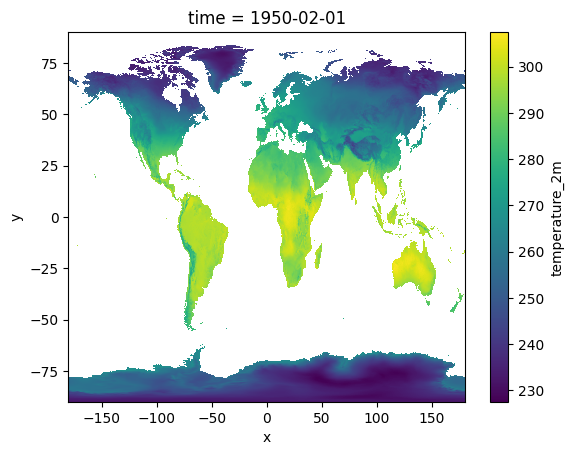

In [1]:
# EXEMPLOS: https://github.com/google/Xee/blob/main/docs/migration-guide-v0.1.0.md

# instala biblioteca
!pip install -q xee

# importa bibliotecas
import ee
import xarray as xr
from xee import helpers
import shapely
import geemap

# inicializando GEE
geemap.ee_initialize(project='ee-enrique',
                     opt_url='https://earthengine-highvolume.googleapis.com')

# Test 1: Open a dataset
ic = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR').limit(5)
grid_params = helpers.extract_grid_params(ic)
ds = xr.open_dataset(ic, engine='ee', **grid_params)

# Test 2: Check dimensions
print("Dimensions:", ds['temperature_2m'].dims)
# Should print: ('time', 'y', 'x')

# Test 3: Plot without transpose
ds['temperature_2m'].isel(time=0).plot()

# Test 4: Verify CRS and transform
print("CRS:", grid_params['crs'])
print("Transform:", grid_params['crs_transform'])
print("Shape:", grid_params['shape_2d'])

# mostra os dados
ds

Exemplo 2:

#--------------------------------------------------------------------------------------------#


<xarray.Dataset> Size: 3MB
Dimensions:         (time: 196, y: 52, x: 82)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2010-01-01 ... 2026-04-01
  * y               (y) float64 416B -19.75 -19.86 -19.96 ... -25.25 -25.36
  * x               (x) float64 656B -53.08 -52.97 -52.86 ... -44.28 -44.17
Data variables:
    temperature_2m  (time, y, x) float32 3MB ...

#--------------------------------------------------------------------------------------------#

Dimensions: ('time', 'y', 'x')
CRS: EPSG:4326
Transform: (0.11, 0.0, -53.13, 0.0, -0.11, -19.69)
Shape: (82, 52)
#--------------------------------------------------------------------------------------------#



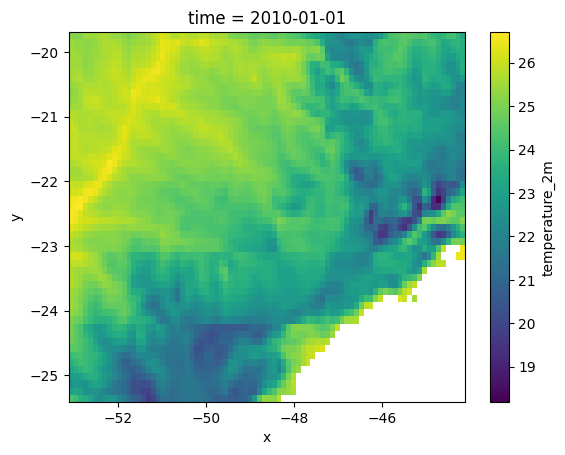

In [9]:
# EXEMPLOS: https://github.com/google/Xee/blob/main/docs/migration-guide-v0.1.0.md

# instala biblioteca
!pip install -q xee

# importa bibliotecas
import ee
import xarray as xr
from xee import helpers
import shapely
from shapely.geometry import shape
import geemap

# inicializando GEE
geemap.ee_initialize(project='ee-enrique',
                     opt_url='https://earthengine-highvolume.googleapis.com')

# shapefile
estado_sp = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM1_NAME', 'Sao Paulo'))

# carrega os dados de t2m
t2m_mensal = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
               .filterDate('2010-01-01','2027-01-01') \
               .filterBounds(estado_sp) \
               .select('temperature_2m') \
               .map(lambda img: img.subtract(273.15).copyProperties(img, img.propertyNames()))

# converte "ee.Geometry" para "shapely geometry" explicitamente
shapely_geometry = shape(estado_sp.geometry().getInfo())

# define os parâmetros
grid_params = helpers.fit_geometry(geometry = shapely_geometry,
                                   grid_crs ='EPSG:4326',
                                   grid_scale =(0.11, -0.11))

# converte para Dataset
ds_t2m_mensal = xr.open_dataset(t2m_mensal,
                                engine = 'ee',
                                **grid_params)

print('#--------------------------------------------------------------------------------------------#')
# mostra os dados
display(ds_t2m_mensal)
print('#--------------------------------------------------------------------------------------------#\n')

# dimensões
print("Dimensions:", ds_t2m_mensal['temperature_2m'].dims) # deveria mostra ('time', 'y', 'x')

# verifica CRS e transform
print("CRS:", grid_params['crs'])
print("Transform:", grid_params['crs_transform'])
print("Shape:", grid_params['shape_2d'])

# plotar sem aplicar transposta
ds_t2m_mensal['temperature_2m'].isel(time=0).plot()
print('#--------------------------------------------------------------------------------------------#\n')

In [10]:
print(-19.745+19.855)

0.10999999999999943


In [12]:
-53.075-0.11

-53.185